# 🧬 pg_bio: The Teaflon Multiomics Pipeline

Welcome to the `pg_bio` interactive tutorial! This notebook demonstrates how to unify **Genomics**, **Proteomics**, and **Transcriptomics** inside a single PostgreSQL database.

We will explore the **Teaflon** scenario: Engineering human cells to produce a synthetic bio-ceramic protein (`Syn-TFLN`) that reinforces the keratin matrix in human nails.

In [1]:
import psycopg
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Connect to the pg_bio database
DB_URL = "postgresql://localhost:28818/bio_demo"
conn = psycopg.connect(DB_URL)

## Step 1: Genomics (Finding a Safe Harbor)
We use PostgreSQL's native `int4range` types and `GiST` indexing to find a safe insertion site for our synthetic gene. The site must be physically adjacent to the `KRT14` (Nail) promoter, but not overlap with any tumor suppressor genes.

In [2]:
query_genomics = """
SELECT 
    safe.feature_name AS safe_harbor_site,
    safe.genomic_range AS insertion_coordinates,
    promoter.feature_name AS nail_promoter
FROM human_genome safe
JOIN human_genome promoter ON safe.chromosome = promoter.chromosome
WHERE safe.feature_type = 'safe_harbor'
  AND promoter.feature_name = 'KRT14_promoter'
  AND GREATEST(lower(safe.genomic_range) - upper(promoter.genomic_range), lower(promoter.genomic_range) - upper(safe.genomic_range), 0) < 5000
  AND NOT EXISTS (
      SELECT 1 FROM human_genome cancer_genes
      WHERE cancer_genes.feature_type = 'tumor_suppressor' AND safe.genomic_range && cancer_genes.genomic_range
  );
"""
df_genomics = pd.read_sql(query_genomics, conn)
display(df_genomics)

,safe_harbor_site,insertion_coordinates,nail_promoter
0,SafeLocus_B,"[41492100, 41496000)",KRT14_promoter


## Step 2: Proteomics (3D Spatial Folding)
Once the gene is transcribed, it folds. We map the 3D atomic point cloud into PostgreSQL using **Z-Order (Morton Coding)**. This unrolls 3D space into a 1D B-Tree index for lightning-fast bounding box queries.

In [3]:
query_proteomics = """
SELECT atom_id, residue_name, atom_type, x, y, z 
FROM teaflon_atoms
WHERE z_curve_index BETWEEN z_order_encode(5.0, -5.0, 20.0) AND z_order_encode(15.0, 5.0, 30.0)
  AND x BETWEEN 5.0 AND 15.0
  AND y BETWEEN -5.0 AND 5.0
  AND z BETWEEN 20.0 AND 30.0
  AND residue_name = 'ARG_BIND'
ORDER BY z ASC LIMIT 5;
"""
df_proteomics = pd.read_sql(query_proteomics, conn)
display(df_proteomics)

,atom_id,residue_name,atom_type,x,y,z
0,508,ARG_BIND,N,11.186101,-2.965975,24.401390
1,506,ARG_BIND,N,9.960833,-3.677927,24.486075
2,502,ARG_BIND,N,9.692639,-4.845616,24.672839
3,518,ARG_BIND,N,12.204274,2.697899,24.791741
4,504,ARG_BIND,N,9.601704,-3.757770,24.854574


## Step 3: Transcriptomics (Single-Cell Dosage)
To ensure the Bio-Teflon doesn't over-harden the nail, we simulate Single-Cell RNA expression. We use **Compressed Sparse Row (CSR)** arrays in PostgreSQL to handle massive sparsity, unnesting them on the fly to calculate RNA dosage.

,cell_type,average_dosage
0,Keratinocyte (Nail),34.935564
1,Osteoblast (Bone),0.512669


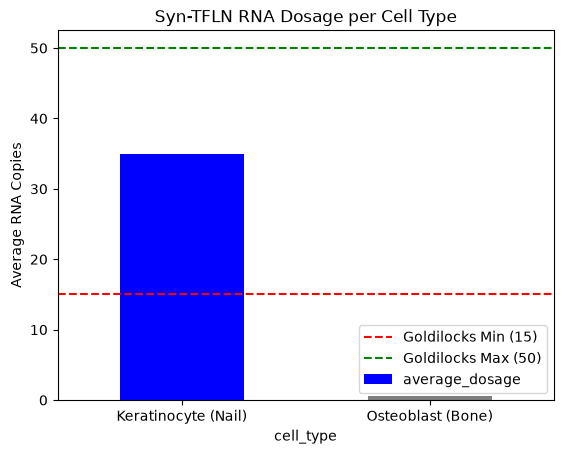

In [4]:
query_transcriptomics = """
WITH unnested_expr AS (
    SELECT cell_type, expr_counts.expr
    FROM single_cell_expression e
    CROSS JOIN LATERAL unnest(e.expressed_gene_ids) WITH ORDINALITY AS gene_ids(g_id, i1)
    JOIN LATERAL unnest(e.expression_counts) WITH ORDINALITY AS expr_counts(expr, i2) ON gene_ids.i1 = expr_counts.i2
    WHERE gene_ids.g_id = 9999
)
SELECT cell_type, AVG(expr) as average_dosage FROM unnested_expr GROUP BY cell_type;
"""
df_transcriptomics = pd.read_sql(query_transcriptomics, conn)
display(df_transcriptomics)

# Plot the Dosage
df_transcriptomics.plot(kind='bar', x='cell_type', y='average_dosage', color=['blue', 'gray'], legend=False)
plt.title('Syn-TFLN RNA Dosage per Cell Type')
plt.ylabel('Average RNA Copies')
plt.xticks(rotation=0)
plt.axhline(y=15, color='r', linestyle='--', label='Goldilocks Min (15)')
plt.axhline(y=50, color='g', linestyle='--', label='Goldilocks Max (50)')
plt.legend()
plt.show()

## Step 4: Joint Vector Spaces (DNA <-> Protein)
Finally, we use `pgvector` to cross biological domains. We calculate the Cosine Distance (`<=>`) between a 1280-dim DNA Enhancer embedding and a 1280-dim Protein embedding directly in SQL.

In [5]:
query_joint = """
WITH protein_target AS (
    SELECT embedding::vector(1280) as emb FROM proteins WHERE uniprot_id = 'P0DPB7'
)
SELECT dna.locus, (dna.embedding <=> pt.emb) as cross_omic_distance
FROM dna_embeddings dna, protein_target pt
ORDER BY cross_omic_distance ASC LIMIT 3;
"""
df_joint = pd.read_sql(query_joint, conn)
display(df_joint)

conn.close()
print("\n\u2728 pg_bio Multiomics Pipeline execution complete! \u2728")

,locus,cross_omic_distance
0,Chr17:Teaflon_Enhancer,0.000000
1,Chr17:Enhancer_9,0.398305
2,Chr17:Enhancer_5,0.407396



✨ pg_bio Multiomics Pipeline execution complete! ✨
